# Benchmarking a DMRG algorithm for QAOA

This notebook benchmarks `DMRGEvaluator`, an implementation of [Ayral et al. , PRX Quantum 4, 020304 (2023)](https://arxiv.org/pdf/2207.05612) via Quimb, and compares it against the MPS evaluators already available in this repository (`MPSEvaluator` and `MPSAerEvaluator`).

## The algorithm

Standard MPS circuit simulation (what `MPSEvaluator` and `MPSAerEvaluator` do) applies gates **one at a time**: each two-qubit gate merges two MPS tensors, and a truncated SVD immediately splits them back apart, discarding the smallest Schmidt values. This is a *greedy, local* compression decision made independently at every gate.

The paper instead proposes:

1. Apply a **block of $K$ two-qubit gates exactly** (no truncation at all), growing the bond dimension freely within the block.
2. **Variationally compress** the resulting state back down to a fixed bond dimension $\chi$ by sweeping through the MPS tensor-by-tensor (a single-site, DMRG-style sweep), at each step solving for the tensor that maximizes the fidelity (overlap) with the exact block output while holding all other tensors fixed. This is an alternating least-squares (ALS) fit, not a sequence of independent local SVDs.
3. Repeat for the next block, using the compressed state as the starting point.

Because the compression step optimizes a whole block of gates *jointly* rather than gate-by-gate, the paper reports it can find a better bond-$\chi$ approximation than greedy SVD truncation, especially for *structured* circuits like QAOA.

## Why quimb

quimb (already a dependency of this repository, and the library underlying `MPSEvaluator`'s own MPS representation) ships a general-purpose 1D tensor-network compression routine, `quimb.tensor.tensor_network_1d_compress`, that supports both:

- `method="dm"`: a density-matrix / direct SVD-based compression (closer to what `MPSEvaluator`/`MPSAerEvaluator` do, just applied to a whole block at once instead of gate-by-gate),
- `method="fit"`: single-site alternating-least-squares sweeps in canonical form — **this is the DMRG-style algorithm from the paper.**


In [1]:
import glob
import json
import time

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import quimb.tensor as qtn
from quimb.tensor import CircuitMPS

from qaoa_training_pipeline.evaluation import (
    EfficientDepthOneEvaluator,
    MPSAerEvaluator,
    MPSEvaluator,
)
from qaoa_training_pipeline.training import DepthOneScanTrainer
from qaoa_training_pipeline.training.fixed_angle_conjecture import FixedAngleConjecture
from qaoa_training_pipeline.utils.graph_utils import (
    graph_to_operator,
    load_graph,
    make_swap_strategy,
    operator_to_list_of_hyper_edges,
)
from qaoa_training_pipeline.utils.tns_utils.qaoa_circuit_mps import (
    QAOACircuitMPSRepresentation,
)
from qaoa_training_pipeline.utils.tns_utils.qaoa_cost_function import QAOACostFunction

rng = np.random.default_rng(3)

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


## Instances to benchmark on

We benchmark in 100-node line-based instances created by starting on a line graph and applying a number of SWAP layers. That gives graphs with different densities. Applying `k = N - 2` layers gives a fully connected graph. We test for `k = 0, 2, 5, 10 ,50 ,8`.


In [2]:
INSTANCE_DIR = "/Users/jju/Desktop/QAOA-Parameter-Setting"
instance_dir = f"{INSTANCE_DIR}/instances/line_to_full"
cuts_dir = f"{INSTANCE_DIR}/data/minmax_cuts/line_to_full"

depths = [1]
n_instances_per_group = 5
swap_layer_counts = [0, 2, 5, 10]
# swap_layer_counts = [0, 2]

depth_one_trainer = DepthOneScanTrainer(EfficientDepthOneEvaluator(), num_points=15)


results_dir = f"{INSTANCE_DIR}/data/training/line_to_full"


def get_params(cost_op, depth, k, idx):
    """Angles for depth 1 come from the (exact) depth-one scan, unchanged from before.

    For depth > 1, first look for real, per-instance angles already computed in the companion
    repo under the "TQA" (Trotterized Quantum Annealing) trainer -- the only trainer we found
    with data for every one of our swap-layer groups at depth 2, and confirmed (by comparing
    across instance indices) to depend on the group's actual structure rather than being a
    graph-agnostic table lookup. If no such file exists for this (depth, k, idx), fall back to
    FixedAngleConjecture. That one requires an *exact* match to a (depth, integer degree) pair in
    its table, and not every degree has data at every depth, so we build a proxy regular graph
    with the closest degree that *is* available at this depth, just to retrieve the (graph-
    agnostic) angles.
    """
    if depth == 1:
        return depth_one_trainer.provide_params(cost_op)["optimized_qaoa_angles"]

    tqa_matches = glob.glob(f"{results_dir}/*{idx:03d}N100L2S{k}_MC_TQA_PP_*_{depth}.json")
    if tqa_matches:
        with open(tqa_matches[0]) as fh:
            return json.load(fh)["0"]["optimized_qaoa_angles"]

    trainer = FixedAngleConjecture(reps=depth)
    available_degrees = sorted({key[1] for key in trainer._data if key[0] == float(depth)})
    n_qubits = cost_op.num_qubits
    avg_degree = 2 * len(operator_to_list_of_hyper_edges(cost_op)) / n_qubits
    closest_degree = int(min(available_degrees, key=lambda d: abs(d - avg_degree)))
    proxy_graph = nx.random_regular_graph(closest_degree, n_qubits, seed=0)
    proxy_cost_op = graph_to_operator(proxy_graph, pre_factor=-0.5)
    return trainer.provide_params(proxy_cost_op)["optimized_qaoa_angles"]


groups = {}
for depth in depths:
    groups[depth] = {}
    for k in swap_layer_counts:
        cost_ops, max_cuts, min_cuts, sums_of_weights, opt_angles = [], [], [], [], []
        for idx in range(n_instances_per_group):
            instance_path = f"{instance_dir}/{idx:03d}_100nodes_{k}swap_layers.json"
            cut_path = f"{cuts_dir}/{idx:03d}_100nodes_{k}swap_layers_maxmin_cut.json"

            graph = load_graph(instance_path)
            cost_op = graph_to_operator(graph, pre_factor=-0.5)  # standard MaxCut convention

            with open(cut_path) as fh:
                cut_info = json.load(fh)

            params = get_params(cost_op, depth, k, idx)

            cost_ops.append(cost_op)
            max_cuts.append(cut_info["max_cut"])
            min_cuts.append(cut_info["min_cut"])
            sums_of_weights.append(cut_info["sum_of_weights"])
            opt_angles.append(params)

        groups[depth][k] = {
            "cost_ops": cost_ops,
            "max_cuts": max_cuts,
            "min_cuts": min_cuts,
            "sums_of_weights": sums_of_weights,
            "opt_angles": opt_angles,
        }
        print(f"depth={depth}, swap_layers={k:3d}: loaded {len(cost_ops)} instances")

depth=1, swap_layers=  0: loaded 5 instances
depth=1, swap_layers=  2: loaded 5 instances
depth=1, swap_layers=  5: loaded 5 instances
depth=1, swap_layers= 10: loaded 5 instances


## A prototype DMRG-style evaluator (gate-level blocks, SWAP-strategy aware)

`DMRGStyleEvaluator` drives this repository's own `QAOACircuitMPSRepresentation` (constructed with truncation fully disabled: `truncation_threshold=None, max_bond_dim=None`) using its existing `_apply_layer_ansatz_swap_strat`/`_apply_mixing_layer` methods, so the SWAP-network gate ordering is exactly the same, already-tested logic `MPSEvaluator(use_swap_strategy=True)` uses internally.

To get **gate-level** block control without re-deriving that gate ordering by hand, `_BlockCompressingCircuit` subclasses `QAOACircuitMPSRepresentation` and overrides only `_apply_two_qubit_gate` (the single method every RZZ *and* every SWAP gate goes through) to count calls and, every `gates_per_block` calls, pull out the MPS, compress it with `tensor_network_1d_compress`, re-canonicalize, and reinject it — all the SWAP/RZZ ordering logic itself is untouched, inherited as-is.

As before, we replicate `MPSEvaluator`'s own correction for the net qubit permutation the SWAP strategy leaves behind after an odd number of QAOA layers.

We validated this against two limits before trusting it:
- **`gates_per_block` very large + `max_bond` very large** (effectively "apply everything exactly, compress once at the very end"): reproduces the exact reference energy to machine precision.
- **`gates_per_block=1`** (compress after literally every single two-qubit gate — the finest possible granularity): reproduces `MPSEvaluator`'s own per-gate greedy-truncation energy almost exactly (0.99475 vs. 0.99475 at $\chi=16$), confirming the two approaches coincide at the fine-grained limit, as they should.

**Limitation of this prototype**: still restricted to quadratic (edge) cost operators and the default QAOA mixer/cost-layer convention; driving the circuit via "private" (underscore-prefixed) methods and overriding another private method works today but is coupled to `QAOACircuitMPSRepresentation`'s internals rather than a supported public API.

In [3]:
class _BlockCompressingCircuit(QAOACircuitMPSRepresentation):
    """Same as QAOACircuitMPSRepresentation, but recompresses to a fixed bond dimension every
    `gates_per_block` individual two-qubit gate applications (RZZ or SWAP), instead of only
    truncating (or not) at the end of a whole QAOA layer.
    """

    # pylint: disable=too-many-positional-arguments
    def configure_compression(self, max_bond, gates_per_block, method, site_tags, compress_opts):
        self._compress_max_bond = max_bond
        self._compress_block = gates_per_block
        self._compress_method = method
        self._site_tags = site_tags
        self._compress_opts = compress_opts
        self._gate_count = 0

    def _apply_two_qubit_gate(self, i_qubit, array, absorb_left):
        result = super()._apply_two_qubit_gate(i_qubit, array, absorb_left)
        self._gate_count += 1
        if self._gate_count % self._compress_block == 0:
            if self._compress_method == "dm":
                # Plain SVD-based block compression -- no ALS-specific options apply here.
                psi = qtn.tensor_network_1d_compress(
                    self.get_underlying_tn(),
                    max_bond=self._compress_max_bond,
                    method="dm",
                    site_tags=self._site_tags,
                    **self._compress_opts,
                )
            else:
                # "fit" -> warm-started (zip-up/TEBD-like guess) single-site ALS sweep, matching
                # the paper's recommended initialization strategy discussed above. `cutoff` is
                # for building that initial guess; `cutoff_fit` (0, i.e. no truncation) is for
                # the ALS sweep itself, which is only meaningful with method="fit-zipup" (the
                # plain "fit" method does not accept `cutoff_fit` at all).
                psi = qtn.tensor_network_1d_compress(
                    self.get_underlying_tn(),
                    max_bond=self._compress_max_bond,
                    method="fit-zipup",
                    initial_bond_dim=self._compress_max_bond,
                    bsz=1,
                    cutoff=1e-10,
                    cutoff_fit=0.0,
                    max_iterations=4,
                    tol=1e-8,
                    normalize=True,
                    site_tags=self._site_tags,
                    **self._compress_opts,
                )

            # `_apply_two_qubit_gate` (the parent class) assumes the MPS it's handed has the
            # same index-naming/axis conventions a natively-built CircuitMPS has (e.g. it looks
            # up bonds positionally via `psi.inner_inds()[i]`). tensor_network_1d_compress's
            # output does not reliably satisfy this -- its inner_inds() come back in an
            # unrelated order, and even after fixing that ordering (via the position-based
            # `.bond(i, i+1)`, not insertion-order-based `inner_inds()`), the parent's internal
            # `shift_orthogonality_center` call can still misbehave on it, causing a *different*
            # tensor/bond to be produced than what `_apply_two_qubit_gate` expects -- surfacing
            # as a `KeyError` on `info[("singular_values", ...)]` a gate or more later. The
            # robust fix is to not reuse tensor_network_1d_compress's internal representation at
            # all: extract the raw site arrays (in the correct leg order) and rebuild a brand
            # new `MatrixProductState` from scratch, which goes through the same construction
            # path as any natively-built MPS and so is guaranteed to satisfy those assumptions.
            arrays = []
            for i, tag in enumerate(self._site_tags):
                tensor = psi[tag]
                if i == 0:
                    order = (f"k{i}", psi.bond(i, i + 1))
                elif i == self.n_qubits - 1:
                    order = (psi.bond(i - 1, i), f"k{i}")
                else:
                    order = (psi.bond(i - 1, i), f"k{i}", psi.bond(i, i + 1))
                arrays.append(tensor.transpose(*order).data)
            fresh_mps = qtn.MatrixProductState(arrays, shape="lpr")
            fresh_mps.canonize(0)

            self._mps_representation = CircuitMPS(self.n_qubits, psi0=fresh_mps)
            self._canonization_center = 0
        return result


class DMRGStyleEvaluator:
    """Prototype of the DMRG-style circuit-compression algorithm of arXiv:2207.05612.

    Drives `QAOACircuitMPSRepresentation` (with truncation disabled) via its SWAP-strategy
    machinery, and compresses back to `max_bond` every `gates_per_block` individual two-qubit
    gates via quimb's `tensor_network_1d_compress` (`method="fit"` = single-site ALS / DMRG-style
    sweep, warm-started from a zip-up guess; `method="dm"` = direct SVD-based block compression).
    """

    def __init__(
        self,
        max_bond,
        growth_max_bond=None,
        gates_per_block=1,
        method="fit",
        swap_strategy=None,
        **compress_opts,
    ):
        self.max_bond = max_bond
        self.growth_max_bond = growth_max_bond
        self.gates_per_block = gates_per_block
        self.method = method
        self.swap_strategy = swap_strategy
        self.compress_opts = compress_opts

    def evaluate(self, cost_op, params) -> float:
        n_qubits = cost_op.num_qubits
        edges = operator_to_list_of_hyper_edges(cost_op)
        if any(len(edge[0]) != 2 for edge in edges):
            raise NotImplementedError("Prototype only supports quadratic (edge) cost operators.")

        depth = len(params) // 2
        betas, gammas = params[:depth], params[depth:]

        swap_strategy = self.swap_strategy or make_swap_strategy(
            [tuple(edge[0]) for edge in edges], n_qubits
        )

        circuit = _BlockCompressingCircuit.construct_from_list_of_edges(
            edges,
            truncation_threshold=None,
            max_bond_dim=self.growth_max_bond,
            swap_strategy=swap_strategy,
        )
        site_tags = tuple(f"I{i}" for i in range(n_qubits))
        circuit.configure_compression(
            self.max_bond, self.gates_per_block, self.method, site_tags, self.compress_opts
        )
        circuit._apply_initial_layer()

        rep = 1
        for layer in range(depth):
            circuit._apply_layer_ansatz_swap_strat(gammas[layer], rep)
            circuit._apply_mixing_layer(betas[layer])
            rep += 1

        # Same net-permutation correction MPSEvaluator applies for use_swap_strategy=True.
        eval_cost_op = cost_op
        if depth % 2 == 1:
            inv_perm = swap_strategy.inverse_composed_permutation(len(swap_strategy))
            permutation = [inv_perm.index(idx) for idx in range(len(inv_perm))]
            eval_cost_op = cost_op.apply_layout(permutation)

        cost_function = QAOACostFunction(eval_cost_op)
        mpo = cost_function.mpo.mpo
        psi = circuit.get_underlying_tn()
        psi_dagger = psi.H
        psi_dagger.reindex_(dict(zip(mpo.lower_inds, mpo.upper_inds)))
        network = psi_dagger & mpo & psi
        energy = network.contract(..., optimize="auto-hq") / psi.norm() ** 2
        return float(np.real(energy))

## Mean approximation ratio and runtime vs. bond dimension for DMRG & MPSEvaluator
The next cell can take substantial amount of time to run depending on the bond dimensions and gate blocks chosen

In [4]:
def approximation_ratio(
    energy: float, sum_of_weights: float, min_cut: float, max_cut: float
) -> float:
    # Normalized cut/optimal-cut ratio: (cut - min_cut) / (max_cut - min_cut). Using plain
    # cut/max_cut would silently assume min_cut == 0, which is false for this (weighted,
    # mixed-sign) instance family -- see markdown above.
    cut_value = energy + 0.5 * sum_of_weights
    return (cut_value - min_cut) / (max_cut - min_cut)

depth=1, chi=4, MPSEvaluator: done
depth=1, chi=4, DMRG (growth unbounded): done
depth=1, chi=4, DMRG (growth bounded = 32): done
depth=1, chi=8, MPSEvaluator: done
depth=1, chi=8, DMRG (growth unbounded): done
depth=1, chi=8, DMRG (growth bounded = 32): done
depth=1, chi=16, MPSEvaluator: done
depth=1, chi=16, DMRG (growth unbounded): done
depth=1, chi=16, DMRG (growth bounded = 32): done
depth=1, chi=32, MPSEvaluator: done


/Users/jju/.pyenv/versions/qaoa_training_pipeline/lib/python3.10/site-packages/quimb/tensor/decomp.py:363: UserWarning: Got: Internal algorithm failed to converge., falling back to scipy gesvd driver.
  warnings.warn(f"Got: {e}, falling back to scipy gesvd driver.")


depth=1, chi=32, DMRG (growth unbounded): done
depth=1, chi=32, DMRG (growth bounded = 32): done


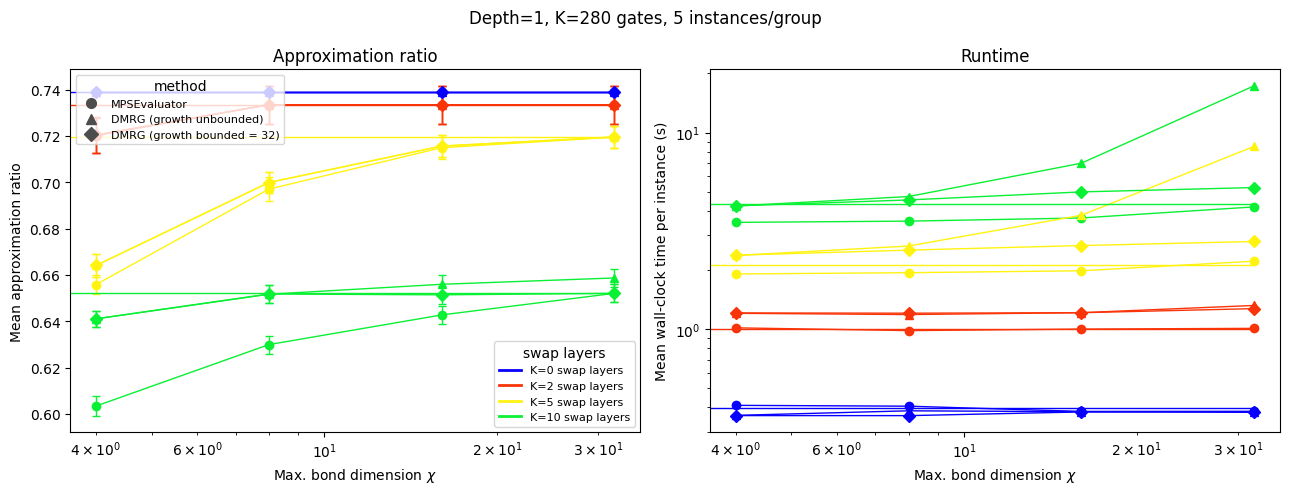

In [8]:
bond_dimensions = [4, 8, 16, 32]

gates_per_block = 280

methods = {
    "MPSEvaluator": lambda chi: MPSEvaluator(
        bond_dim_circuit=chi, threshold_circuit=1e-14, use_swap_strategy=True
    ),
    # "MPSAerEvaluator": lambda chi: MPSAerEvaluator(
    #     {
    #         "matrix_product_state_max_bond_dimension": chi,
    #         "matrix_product_state_truncation_threshold": 1e-14,
    #     }
    # ),
    "DMRG (growth unbounded)": lambda chi: DMRGStyleEvaluator(
        chi, gates_per_block=gates_per_block, method="fit", swap_strategy=None
    ),
    "DMRG (growth bounded = 32)": lambda chi: DMRGStyleEvaluator(
        chi, growth_max_bond=32, gates_per_block=gates_per_block, method="fit", swap_strategy=None
    ),
}

mps_baseline = MPSEvaluator(bond_dim_circuit=32, threshold_circuit=1e-14, use_swap_strategy=True)

swap_colors = {0: "#0800ff", 2: "#f93408", 5: "#fff30f", 10: "#0af034"}
method_markers = {
    "MPSEvaluator": "o",
    "MPSAerEvaluator": "s",
    "DMRG (growth unbounded)": "^",
    "DMRG (growth bounded = 32)": "D",
}

for depth in depths:
    results = {name: {k: {"mean": [], "std": []} for k in swap_layer_counts} for name in methods}
    results_baseline = {k: {"mean": [], "std": []} for k in swap_layer_counts}
    runtimes_baseline = {k: [] for k in swap_layer_counts}

    runtimes = {name: {k: [] for k in swap_layer_counts} for name in methods}

    for chi in bond_dimensions:
        for name, factory in methods.items():
            for k in swap_layer_counts:
                start = time.time()
                ratios = [
                    approximation_ratio(
                        factory(chi).evaluate(cost_op, params), s_weights, m_min, m_max
                    )
                    for cost_op, params, s_weights, m_min, m_max in zip(
                        groups[depth][k]["cost_ops"],
                        groups[depth][k]["opt_angles"],
                        groups[depth][k]["sums_of_weights"],
                        groups[depth][k]["min_cuts"],
                        groups[depth][k]["max_cuts"],
                    )
                ]
                runtimes[name][k].append((time.time() - start) / n_instances_per_group)
                results[name][k]["mean"].append(np.mean(ratios))
                results[name][k]["std"].append(np.std(ratios))
            print(f"depth={depth}, chi={chi}, {name}: done")

    for k in swap_layer_counts:
        start = time.time()
        ratios = [
            approximation_ratio(mps_baseline.evaluate(cost_op, params), s_weights, m_min, m_max)
            for cost_op, params, s_weights, m_min, m_max in zip(
                groups[depth][k]["cost_ops"],
                groups[depth][k]["opt_angles"],
                groups[depth][k]["sums_of_weights"],
                groups[depth][k]["min_cuts"],
                groups[depth][k]["max_cuts"],
            )
        ]
        runtimes_baseline[k].append((time.time() - start) / n_instances_per_group)
        results_baseline[k]["mean"].append(np.mean(ratios))
        results_baseline[k]["std"].append(np.std(ratios))

    fig, (ax_ratio, ax_time) = plt.subplots(1, 2, figsize=(13, 5))

    for name in methods:
        for k in swap_layer_counts:
            ax_ratio.errorbar(
                bond_dimensions,
                results[name][k]["mean"],
                yerr=results[name][k]["std"],
                fmt=method_markers[name] + "-",
                color=swap_colors[k],
                capsize=3,
                markersize=6,
                linewidth=1,
            )
    for k in swap_layer_counts:
        ax_ratio.hlines(
            results_baseline[k]["mean"],
            xmin=0,
            xmax=bond_dimensions[-1],
            color=swap_colors[k],
            linewidth=1,
        )
    ax_ratio.set_xlabel(r"Max. bond dimension $\chi$")
    ax_ratio.set_ylabel("Mean approximation ratio")
    ax_ratio.set_title("Approximation ratio")
    ax_ratio.set_xscale("log")
    for name in methods:
        for k in swap_layer_counts:
            ax_time.plot(
                bond_dimensions,
                runtimes[name][k],
                method_markers[name] + "-",
                color=swap_colors[k],
                markersize=6,
                linewidth=1,
            )
    for k in swap_layer_counts:
        ax_time.hlines(
            runtimes_baseline[k],
            xmin=0,
            xmax=bond_dimensions[-1],
            color=swap_colors[k],
            linewidth=1,
        )
    ax_time.set_xlabel(r"Max. bond dimension $\chi$")
    ax_time.set_ylabel("Mean wall-clock time per instance (s)")
    ax_time.set_title("Runtime")
    ax_time.set_yscale("log")
    ax_time.set_xscale("log")

    # Two separate legends: color = swap-layer count, marker shape = method.
    from matplotlib.lines import Line2D

    color_handles = [
        Line2D([0], [0], color=swap_colors[k], lw=2, label=f"K={k} swap layers")
        for k in swap_layer_counts
    ]
    marker_handles = [
        Line2D(
            [0],
            [0],
            color="0.3",
            marker=method_markers[name],
            linestyle="",
            markersize=7,
            label=name,
        )
        for name in methods
    ]
    legend1 = ax_ratio.legend(
        handles=color_handles, loc="lower right", fontsize=8, title="swap layers"
    )
    ax_ratio.add_artist(legend1)
    ax_ratio.legend(handles=marker_handles, loc="upper left", fontsize=8, title="method")

    fig.suptitle(
        f"Depth={depth}, K={gates_per_block} gates, {n_instances_per_group} instances/group"
    )
    fig.tight_layout()

### Lessons learned
From the experiments run for 100-node line-based instances:
- The number of gates per block matters a lot. For a low number, for example 1 to 20, there is almost no gain over the MPSEvaluator.
- At a higher number of gates per block, for example 50, there is a noticeable accuracy gain.
- This gain in accuracy is especially noticeable at low bond dimension.
- The real gain comes from the fact that the resulting state has lower bond dimension, but reaches better energy values than the vanilla MPS at the same low bond dimension. This might be especially useful if this state needs to be used for something later, like drawing samples.

## Effect of block size

Study the effect of block size in DMRG by sweeping over different block sizes at fixed bond dimension and for an individual line-based instance

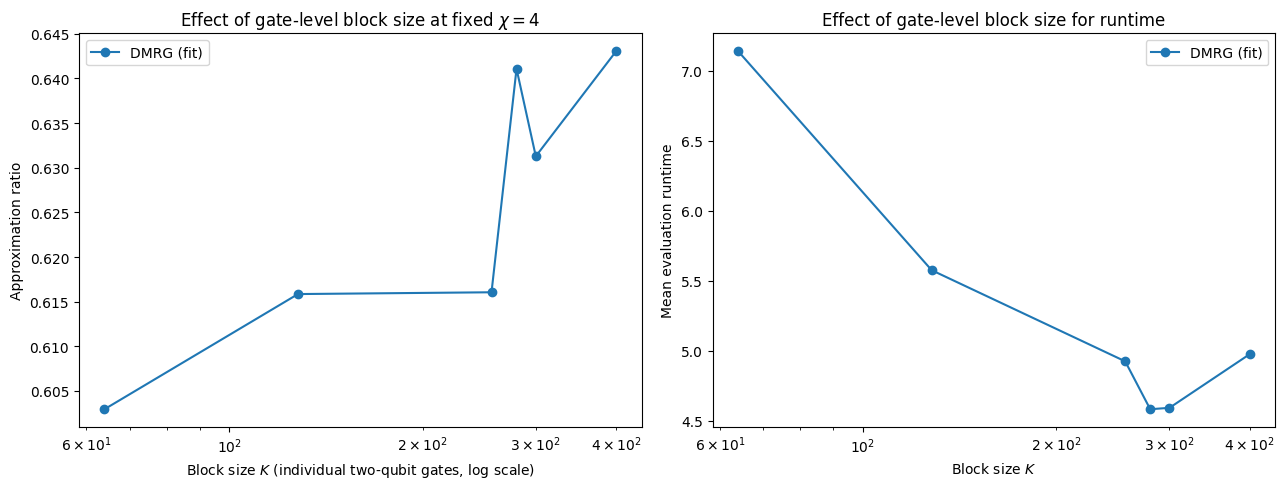

In [ ]:
chi_fixed = 4
gate_block_sizes = [
    # 16,
    # 32,
    64,
    128,
    256,
    280,
    300,
    400,
]

cost_ops = groups[depth][10]["cost_ops"]
params = groups[depth][10]["opt_angles"]
s_weights = groups[depth][10]["sums_of_weights"]
m_maxs = groups[depth][10]["max_cuts"]
m_mins = groups[depth][10]["min_cuts"]

approx_ratio_k = {"DMRG (fit)": []}
runtimes = []
for k in gate_block_sizes:
    ratios = []
    start = time.time()
    for cost_op, params_opt, s_weight, m_min, m_max in zip(
        cost_ops, params, s_weights, m_mins, m_maxs
    ):
        e_fit = DMRGStyleEvaluator(
            chi_fixed, gates_per_block=k, method="fit", swap_strategy=None
        ).evaluate(cost_op, params_opt)
        ratios.append(approximation_ratio(e_fit, s_weight, m_min, m_max))
    approx_ratio_k["DMRG (fit)"].append(np.mean(ratios))
    runtimes.append((time.time() - start) / n_instances_per_group)
fig, (ax, ax_time) = plt.subplots(1, 2, figsize=(13, 5))
ax.plot(gate_block_sizes, approx_ratio_k["DMRG (fit)"], "o-", label="DMRG (fit)")
ax.set_xscale("log")
ax.set_xlabel(r"Block size $K$ (individual two-qubit gates, log scale)")
ax.set_ylabel("Approximation ratio")
ax.set_title(rf"Effect of gate-level block size at fixed $\chi={chi_fixed}$")
ax.legend()
ax_time.plot(gate_block_sizes, runtimes, "o-", label="DMRG (fit)")
ax_time.set_xscale("log")
ax_time.set_xlabel(r"Block size $K$")
ax_time.set_ylabel("Mean evaluation runtime")
ax_time.set_title("Effect of gate-level block size for runtime")
ax_time.legend()
fig.tight_layout()

### Lessons learned
- There is an optimal value for the number of gates in each block. 
- In the first range of values, the cost of performing the fitting to an MPS of fixed $\chi$ every $K$ gates dominates, therefore the reduction in time when increasing $K$.